<a href="https://colab.research.google.com/github/RafispaceML/ProjetoInfla-oxAmparo/blob/main/projetowhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade Presbiteriana Mackenzie
Curso de Ciências Econômicas  CCSA
Programação para Economistas  1º Semestre de 2026


**“Países com maior inflação tendem a ter menores índices de felicidade, ou fatores como saúde e
suporte social são mais correlacionados?”**


Larissa Souza RA: 10763031

Rafaela Leme RA: 10771845

Pedro Gianini RA: 10771759

In [ ]:
#O arquivo CSV foi carregado utilizando pd.read_csv(), criando um DataFrame chamado df. Em seguida, comandos como head(), dtypes, shape, columns e isnull() foram utilizados para compreender a estrutura da base de dados, identificar tipos de variáveis, quantidade de registros e possíveis valores ausentes.

df = pd.read_csv("WHI_Inflation.csv")
print(df.head())
print(df.dtypes)
print(df.shape)
print(df.columns)
print(df)
print(df.isnull())

       Country  Year  Headline Consumer Price Inflation  \
0  Afghanistan  2015                             -0.660   
1  Afghanistan  2016                              4.380   
2  Afghanistan  2017                              4.976   
3  Afghanistan  2018                              0.630   
4  Afghanistan  2019                              2.302   

   Energy Consumer Price Inflation  Food Consumer Price Inflation  \
0                        -4.250000                      -0.840000   
1                         2.070000                       5.670000   
2                         4.440000                       6.940000   
3                         1.474185                      -1.045952   
4                        -2.494359                       3.794770   

   Official Core Consumer Price Inflation  Producer Price Inflation  \
0                                0.219999                       NaN   
1                                5.192760                       NaN   
2                

In [ ]:
import pandas as pd

In [ ]:
print(df.columns.tolist())

['Country', 'Year', 'Headline Consumer Price Inflation', 'Energy Consumer Price Inflation', 'Food Consumer Price Inflation', 'Official Core Consumer Price Inflation', 'Producer Price Inflation', 'GDP deflator Index growth rate', 'Continent/Region', 'Score', 'GDP per Capita', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


In [ ]:
#O método drop() foi utilizado para remover colunas que não seriam utilizadas na pesquisa. Isso reduz a complexidade da análise e mantém o foco nas variáveis relacionadas à inflação, felicidade, amparo social e expectativa de vida.
df.drop(["Energy Consumer Price Inflation","Food Consumer Price Inflation","Official Core Consumer Price Inflation","Producer Price Inflation","GDP deflator Index growth rate","Continent/Region","GDP per Capita","Freedom to make life choices","Generosity","Perceptions of corruption"], axis=1, inplace=True, errors='ignore')

In [ ]:
#Foram verificadas a quantidade de países distintos e a presença de valores nulos. Em seguida, colunas completamente vazias foram removidas utilizando dropna(axis=1, how='all').
print(df)
print("Anos disponíveis: ", sorted(df["Year"].unique()))
print("Country:", df["Country"].nunique())
print("Missings por coluna:")
print(df.isnull().sum())
df = df.dropna(axis=1, how="all")

          Country  Year  Headline Consumer Price Inflation   Score  \
0     Afghanistan  2015                          -0.660000  3.5750   
1     Afghanistan  2016                           4.380000  3.3600   
2     Afghanistan  2017                           4.976000  3.7940   
3     Afghanistan  2018                           0.630000  3.6320   
4     Afghanistan  2019                           2.302000  3.2030   
...           ...   ...                                ...     ...   
1227     Zimbabwe  2019                         255.292007  3.6630   
1228     Zimbabwe  2020                         557.210000  3.2992   
1229     Zimbabwe  2021                          98.546000  3.1450   
1230     Zimbabwe  2022                         104.705171  2.9950   
1231     Zimbabwe  2023                         105.401982  3.2040   

      Social support  Healthy life expectancy at birth  
0           0.302850                          0.303350  
1           0.110370                         

In [ ]:
#Foi criado um subconjunto contendo apenas registros do ano de 2023, garantindo comparações dentro do mesmo período temporal
df_2023 = df[df["Ano"] == 2023]
print(df_2023)

             Pais   Ano    Inflação  Felicidade  Amparo  Expectativa
8     Afghanistan  2023         NaN       1.859   0.000        0.087
17        Albania  2023    5.565224       5.277   0.951        0.480
26        Algeria  2023    9.322174       5.329   1.298        0.409
39      Argentina  2023  128.414708       6.024   1.388        0.427
48        Armenia  2023    1.980419       5.342   1.134        0.443
...           ...   ...         ...         ...     ...          ...
1195      Uruguay  2023    5.869104       6.494   1.445        0.435
1204   Uzbekistan  2023    9.951000       6.014   1.347        0.375
1213      Vietnam  2023    3.252893       5.763   1.212        0.381
1222       Zambia  2023   10.953000       3.982   0.890        0.095
1231     Zimbabwe  2023  105.401982       3.204   0.881        0.069

[122 rows x 6 columns]


In [ ]:
#Utilizou-se groupby() combinado com mean() para calcular médias de felicidade associadas a diferentes níveis de inflação e amparo social. O método reset_index() reorganizou os resultados em formato tabular.
df.groupby("Inflação")["Felicidade"].mean().reset_index()
#Usei o Gemini(esqueci que tinha que colocar .reset_index())
#Inflação Baixa (perto de 0/Menor que 0 - Deflação), Inflação Média (Entre 0 e )
#Usei o Gemini para entender qual a validade de utilizar a média da Felicidade.

,Inflação,Felicidade
0,-3.752996,4.8390
1,-3.233000,4.5870
2,-2.894000,4.3900
3,-2.810000,2.9050
4,-2.520000,4.6280
...,...,...
1173,189.436409,2.9550
1174,221.341644,2.3920
1175,255.292007,3.6630
1176,379.848999,3.8320


In [ ]:
df.groupby("Amparo")["Felicidade"].mean().reset_index()
#Utilizei o Gemini para entender qual a validade de utilizar a média da felicidade para o amparo

,Amparo,Felicidade
0,0.000000,2.900211
1,0.058000,5.045000
2,0.062000,3.775000
3,0.064000,4.623000
4,0.104190,3.484000
...,...,...
1058,1.601000,7.324000
1059,1.610574,7.504000
1060,1.620000,7.530000
1061,1.624000,7.494000


In [ ]:
print(df)

             Pais   Ano    Inflação  Felicidade    Amparo  Expectativa
0     Afghanistan  2015   -0.660000      3.5750  0.302850     0.303350
1     Afghanistan  2016    4.380000      3.3600  0.110370     0.173440
2     Afghanistan  2017    4.976000      3.7940  0.581543     0.180747
3     Afghanistan  2018    0.630000      3.6320  0.537000     0.255000
4     Afghanistan  2019    2.302000      3.2030  0.517000     0.361000
...           ...   ...         ...         ...       ...          ...
1227     Zimbabwe  2019  255.292007      3.6630  1.114000     0.433000
1228     Zimbabwe  2020  557.210000      3.2992  1.047835     0.375038
1229     Zimbabwe  2021   98.546000      3.1450  0.649000     0.243000
1230     Zimbabwe  2022  104.705171      2.9950  0.690000     0.270000
1231     Zimbabwe  2023  105.401982      3.2040  0.881000     0.069000

[1232 rows x 6 columns]


In [ ]:
#Os dados de 2023 foram agrupados por país e tiveram suas médias calculadas para Amparo, Felicidade, Expectativa de Vida e Inflação. Os valores foram arredondados para duas casas decimais.
Dados_2023 = (df[df["Ano"] == 2023]
            .groupby("Pais")[["Amparo", "Felicidade", "Expectativa","Inflação"]]
            .mean()
            .round(2)
            .reset_index())
print(f"Dados {2023} — indicadores por País:")
print(Dados_2023)
#calculamos a media dos indicadores por pais no ano de 2023

Dados 2023 — indicadores por País:
            Pais  Amparo  Felicidade  Expectativa  Inflação
0    Afghanistan    0.00        1.86         0.09       NaN
1        Albania    0.95        5.28         0.48      5.57
2        Algeria    1.30        5.33         0.41      9.32
3      Argentina    1.39        6.02         0.43    128.41
4        Armenia    1.13        5.34         0.44      1.98
..           ...     ...         ...          ...       ...
117      Uruguay    1.44        6.49         0.44      5.87
118   Uzbekistan    1.35        6.01         0.38      9.95
119      Vietnam    1.21        5.76         0.38      3.25
120       Zambia    0.89        3.98         0.10     10.95
121     Zimbabwe    0.88        3.20         0.07    105.40

[122 rows x 5 columns]


In [ ]:
#Os métodos max() e min() permitiram identificar os extremos de inflação e amparo social observados na amostra.
Inflação_max = Dados_2023["Inflação"].max()
print(f"inflação máxima em 2023: {Inflação_max}")
Inflação_min = Dados_2023["Inflação"].min()
print(f"inflação mínima em 2023: {Inflação_min}")

inflação máxima em 2023: 221.34
inflação mínima em 2023: 0.18


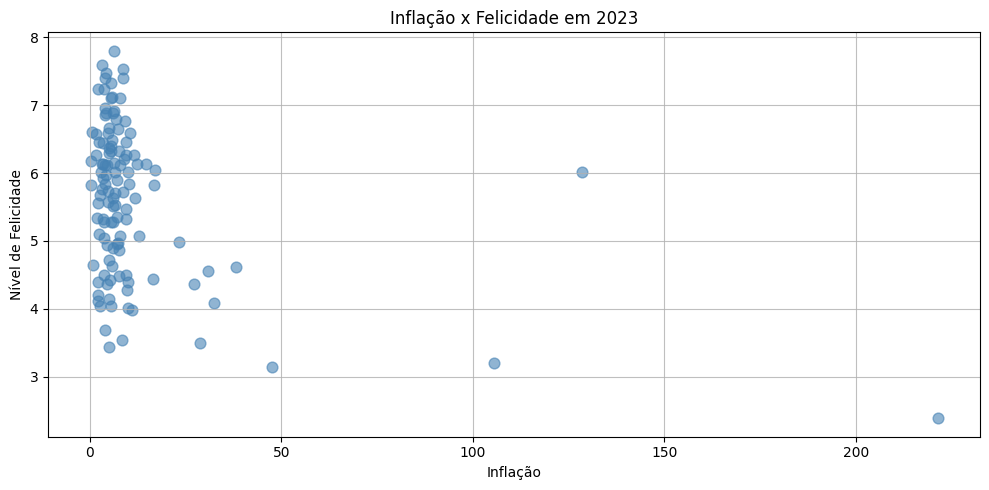

In [ ]:
#A biblioteca Matplotlib foi utilizada para criar gráficos de dispersão (scatter plots), permitindo observar visualmente possíveis relações entre inflação, felicidade, expectativa de vida e amparo social.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(Dados_2023['Inflação'],Dados_2023['Felicidade'], alpha=0.6, color="steelblue", s=60)
plt.title("Inflação x Felicidade em 2023")
plt.xlabel("Inflação")
plt.ylabel("Nível de Felicidade")
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

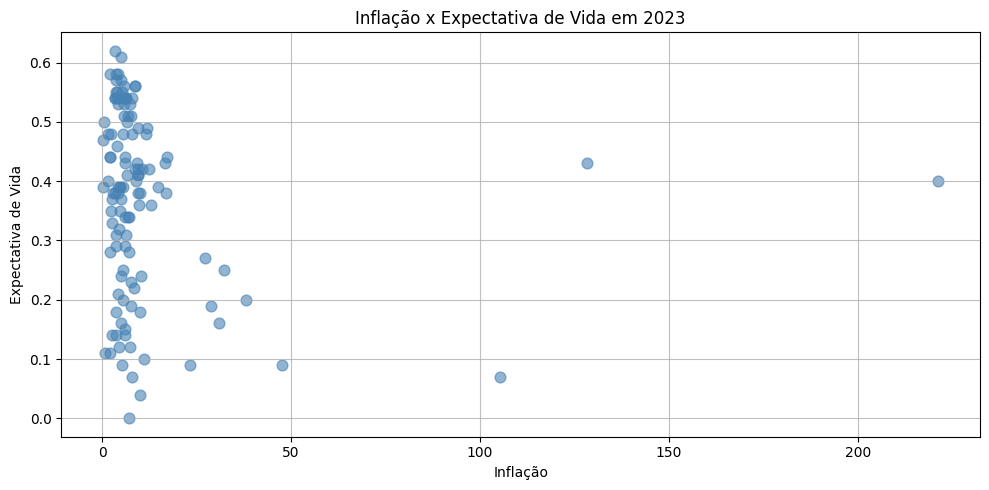

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(Dados_2023["Inflação"],Dados_2023["Expectativa"], alpha=0.6, color="steelblue", s=60)
plt.title("Inflação x Expectativa de Vida em 2023")
plt.xlabel("Inflação")
plt.ylabel("Expectativa de Vida")
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()
# Usei Gemini, estava dando erro: Escrevi Sacatter ao invez de Scatter.

In [ ]:
Amparo_max = Dados_2023["Amparo"].max()
print(f"Amparo maximo em 2023: {Amparo_max}")
Amparo_min = Dados_2023["Amparo"].min()
print(f"Amparo minimo em 2023: {Amparo_min}")

Amparo maximo em 2023: 1.62
Amparo minimo em 2023: 0.0


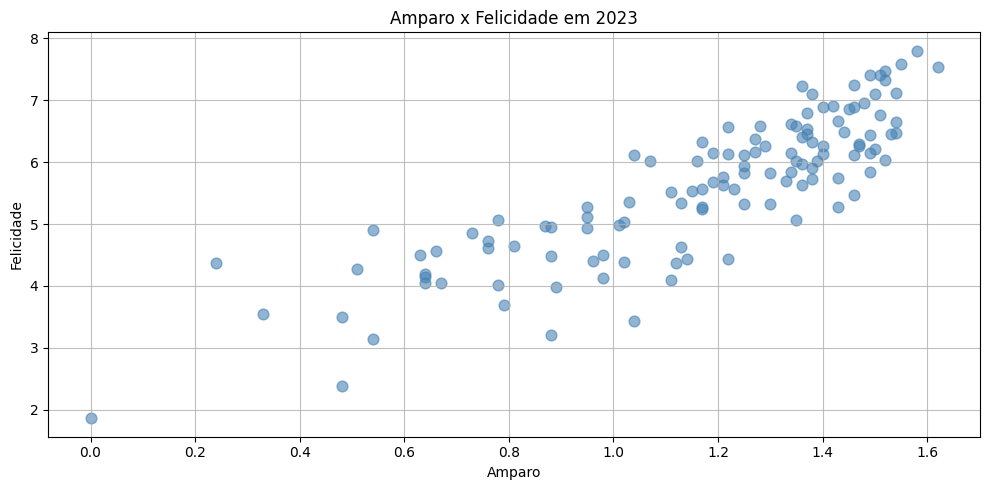

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(Dados_2023["Amparo"],Dados_2023["Felicidade"], alpha=0.6, color="steelblue", s=60)
plt.title("Amparo x Felicidade em 2023")
plt.xlabel("Amparo")
plt.ylabel("Felicidade")
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

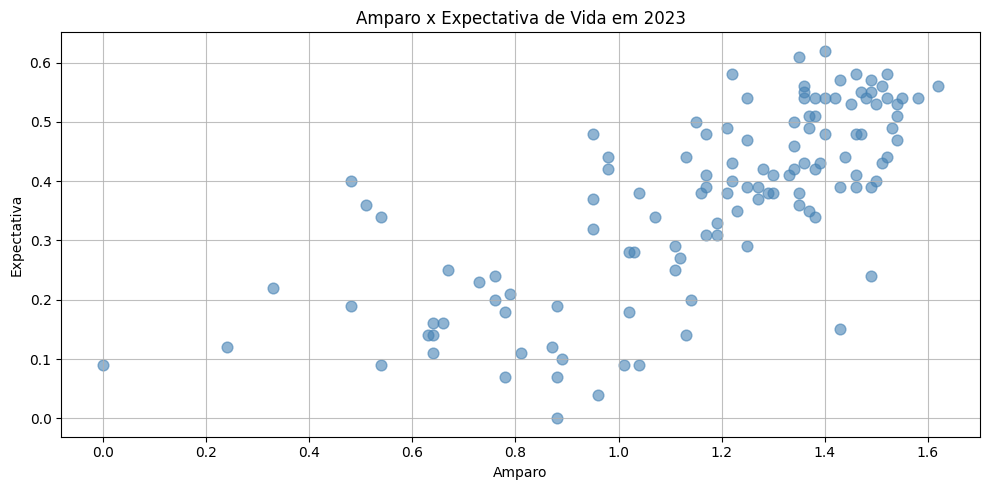

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(Dados_2023["Amparo"],Dados_2023["Expectativa"], alpha=0.6, color="steelblue", s=60)
plt.title("Amparo x Expectativa de Vida em 2023")
plt.xlabel("Amparo")
plt.ylabel("Expectativa")
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

In [ ]:
#Os países foram ordenados utilizando sort_values(). Em seguida, os 10 maiores e os 10 menores valores de inflação foram selecionados para comparação das médias de felicidade.
Top10_maiorInflação = Dados_2023.sort_values(by='Inflação', ascending=False).head(10)
FelicidadeMedia_Top10MaiorIn = Top10_maiorInflação['Felicidade'].mean()

print("10 países com maior Inflação")
print(Top10_maiorInflação[['Pais', 'Inflação', 'Felicidade']])
print(f"Felicidade média para os 10 países com maior inflação em 2023: {FelicidadeMedia_Top10MaiorIn}")

10 países com maior Inflação
             Pais  Inflação  Felicidade
59        Lebanon    221.34        2.39
3       Argentina    128.41        6.02
121      Zimbabwe    105.40        3.20
97   Sierra Leone     47.64        3.14
39          Ghana     38.11        4.61
33       Ethiopia     32.30        4.09
86       Pakistan     30.77        4.56
64         Malawi     28.79        3.50
76        Myanmar     27.10        4.37
83        Nigeria     23.32        4.98
Felicidade média para os 10 países com maior inflação em 2023: 4.086


In [ ]:
Top10_menorInflacao = Dados_2023.sort_values(by='Inflação', ascending=True).head(10)
FelicidadeMedia_Top10MenorIn = Top10_menorInflacao['Felicidade'].mean()

print("Os 10 países com menor inflação em 2023 são:")
print(Top10_menorInflacao[['Pais', 'Inflação', 'Felicidade',]])
print(f"Felicidade média para os 10 países com menor inflação em 2023: {FelicidadeMedia_Top10MenorIn}")

Os 10 países com menor inflação em 2023 são:
                     Pais  Inflação  Felicidade
7                 Bahrain      0.18        6.17
22                  China      0.23        5.82
25             Costa Rica      0.53        6.61
16           Burkina Faso      0.74        4.64
87                 Panama      1.49        6.26
114  United Arab Emirates      1.62        6.57
4                 Armenia      1.98        5.34
66                   Mali      2.06        4.20
54                 Jordan      2.08        4.12
17               Cambodia      2.13        4.39
Felicidade média para os 10 países com menor inflação em 2023: 5.412


In [ ]:
#O mesmo procedimento foi realizado para o indicador de amparo social, permitindo avaliar sua possível influência sobre os níveis médios de felicidade.
Top10_menorAmparo = Dados_2023.sort_values(by='Amparo', ascending=True).head(10)
FelicidadeMedia_Top10MenorAm = Top10_menorAmparo['Felicidade'].mean()

print("Os 10 países com menor Amparo Social em 2023 são:")
print(Top10_menorAmparo[['Pais', 'Amparo', 'Felicidade']])
print(f"\nFelicidade média para os 10 países com menor Amparo Social em 2023: {FelicidadeMedia_Top10MenorAm}")

Os 10 países com menor Amparo Social em 2023 são:
            Pais  Amparo  Felicidade
0    Afghanistan    0.00        1.86
10         Benin    0.24        4.37
24       Comoros    0.33        3.54
59       Lebanon    0.48        2.39
64        Malawi    0.48        3.50
8     Bangladesh    0.51        4.28
74       Morocco    0.54        4.90
97  Sierra Leone    0.54        3.14
82         Niger    0.63        4.50
60       Liberia    0.64        4.04

Felicidade média para os 10 países com menor Amparo Social em 2023: 3.652


In [ ]:
Top10_maiorAmparo = Dados_2023.sort_values(by='Amparo', ascending=False).head(10)
FelicidadeMedia_Top10MaiorAm= Top10_maiorAmparo['Felicidade'].mean()

print("Os 10 países com maior Amparo Social em 2023 são:")
print(Top10_maiorAmparo[['Pais', 'Amparo', 'Felicidade']])
print(f"Felicidade média para os 10 países com maior Amparo Social em 2023: {FelicidadeMedia_Top10MaiorAm}")

Os 10 países com maior Amparo Social em 2023 são:
            Pais  Amparo  Felicidade
45       Iceland    1.62        7.53
34       Finland    1.58        7.80
28       Denmark    1.55        7.59
99      Slovakia    1.54        6.47
100     Slovenia    1.54        6.65
80   New Zealand    1.54        7.12
32       Estonia    1.53        6.46
85        Norway    1.52        7.32
50        Israel    1.52        7.47
44       Hungary    1.52        6.04

Felicidade média para os 10 países com maior Amparo Social em 2023: 7.045
